In [21]:
!pip install grandiso


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [22]:
"""
gSpan-style Frequent Subgraph Mining on a Single Large Graph
============================================================
Supports three anti-monotone support measures:
  - MNI  : Minimum Node Image          (fast, O(embeddings), may overcount)
  - MIS  : Maximum Independent Set     (exact but NP-hard; greedy approx used)
  - HO   : Harmful Overlap             (middle ground; MIS on HO-overlap graph)

Dependencies:
    pip install networkx grandiso

Usage:
    python gspan_single_graph.py
"""

from __future__ import annotations

import sys
import time
from collections import defaultdict
from itertools import combinations
from typing import Literal

import networkx as nx

# ---------------------------------------------------------------------------
# Optional: use grandiso for faster embedding enumeration.
# Falls back to NetworkX VF2 automatically if not installed.
# ---------------------------------------------------------------------------
try:
    from grandiso import find_motifs as _grandiso_find

    def _get_embeddings(G: nx.Graph, pattern: nx.Graph) -> list[dict]:
        """
        Return all subgraph embeddings of `pattern` in `G`.
        Each embedding is {pattern_node: host_node}.
        grandiso returns {pattern_node: host_node} dicts directly.
        """
        return _grandiso_find(pattern, G)

    _BACKEND = "grandiso"

except ImportError:
    def _get_embeddings(G: nx.Graph, pattern: nx.Graph) -> list[dict]:
        """
        Fallback: NetworkX VF2.
        VF2 returns {host_node: pattern_node}; we invert to {pattern_node: host_node}.
        """
        nm = nx.algorithms.isomorphism.categorical_node_match("label", "")
        gm = nx.algorithms.isomorphism.GraphMatcher(G, pattern, node_match=nm)
        return [
            {p: h for h, p in iso.items()}
            for iso in gm.subgraph_isomorphisms_iter()
        ]

    _BACKEND = "networkx-vf2"


# ============================================================
#  Support measures
# ============================================================

def support_mni(embeddings: list[dict], _pattern: nx.Graph = None) -> int:
    """
    Minimum Node Image support.

    For each pattern node v, collect the set of all host-graph nodes
    it maps to across every embedding. Return the minimum set size.

    Complexity: O(|embeddings| * |pattern|)
    Always >= MIS >= 0. Anti-monotone.
    """
    if not embeddings:
        return 0
    images: dict[object, set] = defaultdict(set)
    for iso in embeddings:
        for p_node, g_node in iso.items():
            images[p_node].add(g_node)
    return min(len(s) for s in images.values())


def _greedy_mis(adj: list[set], n: int) -> int:
    """
    Greedy Maximum Independent Set on an overlap graph with n nodes.
    Always picks the node with the fewest remaining neighbours.
    Gives a good approximation; exact MIS is NP-hard.
    """
    remaining = set(range(n))
    count = 0
    while remaining:
        v = min(remaining, key=lambda x: len(adj[x] & remaining))
        count += 1
        remaining -= {v} | (adj[v] & remaining)
    return count


def _build_overlap_graph(
    embeddings: list[dict],
    harmful_only: bool,
) -> tuple[list[set], int]:
    """
    Build the overlap graph O for a list of embeddings.

    - harmful_only=False  →  MIS mode: edge between any two embeddings that
                              share at least one host-graph node.
    - harmful_only=True   →  HO mode:  edge only when two embeddings share a
                              host-graph node AND map it to the *same* pattern
                              node (a 'harmful' ancestor conflict).

    Returns (adjacency_list, n_nodes).
    """
    n = len(embeddings)
    adj: list[set] = [set() for _ in range(n)]

    # Pre-compute inverted maps {host_node: pattern_node} for HO mode
    inv = [{g: p for p, g in iso.items()} for iso in embeddings] if harmful_only else []

    for i, j in combinations(range(n), 2):
        shared = set(embeddings[i].values()) & set(embeddings[j].values())
        if not shared:
            continue
        if not harmful_only:
            adj[i].add(j)
            adj[j].add(i)
        else:
            # Harmful only when the shared host-node fills the SAME pattern role
            if any(inv[i].get(h) == inv[j].get(h) for h in shared):
                adj[i].add(j)
                adj[j].add(i)

    return adj, n


def support_mis(embeddings: list[dict], _pattern: nx.Graph = None) -> int:
    """
    Maximum Independent Set support.

    Build the full overlap graph (edge = any shared host node) and return
    the size of its MIS via greedy approximation.

    Complexity: O(|embeddings|^2) for graph construction + greedy MIS.
    MIS <= HO <= MNI. Anti-monotone.
    """
    if not embeddings:
        return 0
    adj, n = _build_overlap_graph(embeddings, harmful_only=False)
    return _greedy_mis(adj, n)


def support_ho(embeddings: list[dict], _pattern: nx.Graph = None) -> int:
    """
    Harmful Overlap support (Fiedler & Borgelt 2007).

    Like MIS but only 'harmful' overlaps (shared host node maps to the same
    pattern node) generate edges in the overlap graph. This gives a sparser
    graph, so HO >= MIS always.

    Complexity: O(|embeddings|^2). Anti-monotone.
    """
    if not embeddings:
        return 0
    adj, n = _build_overlap_graph(embeddings, harmful_only=True)
    return _greedy_mis(adj, n)


# Map string names to functions
SUPPORT_FNS = {
    "mni": support_mni,
    "mis": support_mis,
    "ho":  support_ho,
}

Measure = Literal["mni", "mis", "ho"]


# ============================================================
#  Canonical DFS code (pattern deduplication)
# ============================================================

def _canonical_key(P: nx.Graph) -> tuple:
    """
    Produce a canonical hashable key for an undirected labelled pattern graph
    so we don't explore the same pattern twice via different growth orders.

    Strategy: sort-stable Weisfeiler-Lehman node relabelling, then
    represent as a sorted edge list of label pairs + sorted node label list.
    This is not a true canonical form for all graphs but is correct for the
    small patterns (≤ ~6 nodes) encountered in practice here.
    """
    node_labels = tuple(sorted(d["label"] for _, d in P.nodes(data=True)))
    edge_labels = tuple(
        sorted(
            tuple(sorted([P.nodes[u]["label"], P.nodes[v]["label"]]))
            for u, v in P.edges()
        )
    )
    return (node_labels, edge_labels, P.number_of_edges())


# ============================================================
#  Seed pattern generation (all distinct single-edge patterns)
# ============================================================

def _seed_patterns(G: nx.Graph) -> list[nx.Graph]:
    """
    Generate all distinct single-edge labelled patterns from G.
    Each seed is a 2-node graph with the canonical label ordering.
    """
    seen: set[tuple] = set()
    seeds: list[nx.Graph] = []
    for u, v in G.edges():
        la, lb = G.nodes[u]["label"], G.nodes[v]["label"]
        key = tuple(sorted([la, lb]))
        if key not in seen:
            seen.add(key)
            P = nx.Graph()
            P.add_node(0, label=la)
            P.add_node(1, label=lb)
            P.add_edge(0, 1)
            seeds.append(P)
    return seeds


# ============================================================
#  Pattern extension (one new node + edge per call)
# ============================================================

def _extend(P: nx.Graph, label_set: set[str]) -> list[nx.Graph]:
    """
    Return all single-node extensions of pattern P.
    For each existing pattern node and each possible label, attach a new leaf.
    Duplicates are deduplicated by canonical key before returning.
    """
    seen: set[tuple] = set()
    extensions: list[nx.Graph] = []
    for pnode in list(P.nodes()):
        for lbl in label_set:
            cand = P.copy()
            new_id = max(cand.nodes()) + 1
            cand.add_node(new_id, label=lbl)
            cand.add_edge(pnode, new_id)
            key = _canonical_key(cand)
            if key not in seen:
                seen.add(key)
                extensions.append(cand)
    return extensions


# ============================================================
#  Main mining loop
# ============================================================

def gspan_single_graph(
    G: nx.Graph,
    min_support: int = 2,
    max_nodes: int = 4,
    measure: Measure = "mni",
    verbose: bool = True,
) -> list[tuple[nx.Graph, int]]:
    """
    gSpan-style DFS frequent subgraph mining on a single large graph.

    Parameters
    ----------
    G           : Host graph. Every node must have a 'label' attribute.
    min_support : Minimum support threshold τ.
    max_nodes   : Maximum pattern size (number of nodes) to explore.
    measure     : One of 'mni', 'mis', 'ho'.
    verbose     : Print progress to stdout.

    Returns
    -------
    List of (pattern_graph, support_value) tuples, sorted by support descending.
    """
    if measure not in SUPPORT_FNS:
        raise ValueError(f"measure must be one of {list(SUPPORT_FNS)}; got {measure!r}")

    freq_fn = SUPPORT_FNS[measure]
    label_set = {d["label"] for _, d in G.nodes(data=True)}

    if verbose:
        print(f"\n{'='*60}")
        print(f"  gSpan Single-Graph Mining")
        print(f"  Backend      : {_BACKEND}")
        print(f"  Measure      : {measure.upper()}")
        print(f"  Min support  : {min_support}")
        print(f"  Max nodes    : {max_nodes}")
        print(f"  Graph        : {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
        print(f"  Labels       : {sorted(label_set)}")
        print(f"{'='*60}\n")

    frequent: list[tuple[nx.Graph, int]] = []
    queue: list[nx.Graph] = []
    visited_keys: set[tuple] = set()

    # --- Phase 1: seed patterns (single edges) ---
    t0 = time.perf_counter()
    for seed in _seed_patterns(G):
        key = _canonical_key(seed)
        if key in visited_keys:
            continue
        visited_keys.add(key)
        embs = _get_embeddings(G, seed)
        sup = freq_fn(embs, seed)
        if sup >= min_support:
            frequent.append((seed, sup))
            queue.append(seed)
            if verbose:
                labs = [seed.nodes[n]["label"] for n in sorted(seed.nodes())]
                print(f"  [seed] {labs}  support={sup}")

    # --- Phase 2: DFS extension ---
    while queue:
        pat = queue.pop()
        if pat.number_of_nodes() >= max_nodes:
            continue
        for ext in _extend(pat, label_set):
            key = _canonical_key(ext)
            if key in visited_keys:
                continue
            visited_keys.add(key)
            embs = _get_embeddings(G, ext)
            sup = freq_fn(embs, ext)
            if sup >= min_support:
                frequent.append((ext, sup))
                queue.append(ext)
                if verbose:
                    labs = [ext.nodes[n]["label"] for n in sorted(ext.nodes())]
                    print(f"  [ext]  {labs}  support={sup}")

    elapsed = time.perf_counter() - t0
    frequent.sort(key=lambda x: x[1], reverse=True)

    if verbose:
        print(f"\n  Found {len(frequent)} frequent pattern(s) in {elapsed:.3f}s\n")

    return frequent


# ============================================================
#  Results display
# ============================================================

def print_results(results: list[tuple[nx.Graph, int]], measure: str) -> None:
    print(f"\n{'─'*60}")
    print(f"  Results  ({measure.upper()} support)")
    print(f"{'─'*60}")
    for i, (pat, sup) in enumerate(results, 1):
        nodes = ", ".join(
            f"{n}:{pat.nodes[n]['label']}" for n in sorted(pat.nodes())
        )
        edges = list(pat.edges())
        print(f"  #{i:02d}  support={sup}  nodes=[{nodes}]  edges={edges}")
    print(f"{'─'*60}\n")


def compare_measures(
    G: nx.Graph,
    candidates: list[nx.Graph],
    label: str = "",
) -> None:
    """
    For a fixed list of candidate patterns, print a side-by-side
    comparison of MNI / MIS / HO support values.
    """
    print(f"\n{'='*70}")
    print(f"  Support measure comparison{' — ' + label if label else ''}")
    print(f"  {'Pattern':<30} {'MNI':>6} {'HO':>6} {'MIS':>6}")
    print(f"{'─'*70}")
    for pat in candidates:
        embs = _get_embeddings(G, pat)
        mni = support_mni(embs, pat)
        ho  = support_ho(embs, pat)
        mis = support_mis(embs, pat)
        labs = [pat.nodes[n]["label"] for n in sorted(pat.nodes())]
        edge_str = str(list(pat.edges()))
        row = f"{labs} {edge_str}"[:30]
        print(f"  {row:<30} {mni:>6} {ho:>6} {mis:>6}")
    print(f"{'='*70}\n")


# ============================================================
#  Graph builders for examples
# ============================================================

def make_chain_graph() -> nx.Graph:
    """A-B-A-B-A chain — illustrates MIS < HO < MNI difference."""
    G = nx.Graph()
    for i, lbl in enumerate(["A", "B", "A", "B", "A"]):
        G.add_node(i, label=lbl)
    G.add_edges_from([(0, 1), (1, 2), (2, 3), (3, 4)])
    return G


def make_social_graph() -> nx.Graph:
    """Slightly denser graph with three label types."""
    G = nx.Graph()
    nodes = [
        (0, "A"), (1, "B"), (2, "A"), (3, "C"),
        (4, "B"), (5, "A"), (6, "C"), (7, "B"),
        (8, "A"), (9, "C"),
    ]
    for nid, lbl in nodes:
        G.add_node(nid, label=lbl)
    G.add_edges_from([
        (0, 1), (1, 2), (2, 3), (3, 4),
        (4, 5), (5, 6), (6, 7), (7, 0),
        (1, 5), (2, 6), (3, 7), (8, 1),
        (8, 4), (9, 2), (9, 5),
    ])
    return G


def make_bioinformatics_graph() -> nx.Graph:
    """Protein-protein interaction style graph (P/Q/R labels)."""
    G = nx.Graph()
    nodes = [
        (0, "P"), (1, "Q"), (2, "R"), (3, "P"),
        (4, "Q"), (5, "R"), (6, "P"), (7, "Q"),
    ]
    for nid, lbl in nodes:
        G.add_node(nid, label=lbl)
    G.add_edges_from([
        (0, 1), (1, 2), (2, 3), (3, 4),
        (4, 5), (0, 3), (1, 4), (2, 5),
        (5, 6), (6, 7), (7, 4),
    ])
    return G


# ============================================================
#  Entry point
# ============================================================

def main() -> None:
    print("\n" + "=" * 60)
    print("  Example 1: Chain graph  A-B-A-B-A")
    print("  Shows the MIS < HO < MNI ordering most clearly")
    print("=" * 60)

    G_chain = make_chain_graph()

    # Build the key candidate patterns manually to compare measures side-by-side
    edge_ab = nx.Graph()
    edge_ab.add_node(0, label="A"); edge_ab.add_node(1, label="B")
    edge_ab.add_edge(0, 1)

    path_aba = nx.Graph()
    path_aba.add_node(0, label="A"); path_aba.add_node(1, label="B")
    path_aba.add_node(2, label="A"); path_aba.add_edge(0, 1); path_aba.add_edge(1, 2)

    compare_measures(G_chain, [edge_ab, path_aba], label="chain A-B-A-B-A")

    # Full mine with each measure
    for measure in ("mni", "ho", "mis"):
        results = gspan_single_graph(
            G_chain,
            min_support=2,
            max_nodes=4,
            measure=measure,
            verbose=False,
        )
        print(f"  [{measure.upper()}]  {len(results)} frequent pattern(s) at τ=2")
        print_results(results, measure)

    # ----------------------------------------------------------------
    print("\n" + "=" * 60)
    print("  Example 2: Social graph (A/B/C labels)")
    print("=" * 60)

    G_social = make_social_graph()
    results = gspan_single_graph(
        G_social,
        min_support=3,
        max_nodes=4,
        measure="mni",
        verbose=True,
    )
    print_results(results, "mni")

    # ----------------------------------------------------------------
    print("\n" + "=" * 60)
    print("  Example 3: Bioinformatics graph (P/Q/R labels)")
    print("=" * 60)

    G_bio = make_bioinformatics_graph()
    results = gspan_single_graph(
        G_bio,
        min_support=2,
        max_nodes=4,
        measure="mni",
        verbose=True,
    )
    print_results(results, "mni")

    # ----------------------------------------------------------------
    print("\n" + "=" * 60)
    print("  Example 4: sklearn feature matrix from frequent patterns")
    print("=" * 60)
    _sklearn_demo()


def _sklearn_demo() -> None:
    """
    Demonstrate converting frequent subgraph patterns into a binary
    feature matrix for use with any sklearn classifier.
    """
    try:
        from sklearn.ensemble import RandomForestClassifier
        from sklearn.model_selection import cross_val_score
        from sklearn.pipeline import Pipeline
        from sklearn.preprocessing import StandardScaler
        import numpy as np
    except ImportError:
        print("  (sklearn not installed — skipping classifier demo)")
        print("  Install with: pip install scikit-learn numpy")
        return

    # Create a toy dataset: 6 small graphs, half class-0, half class-1
    def _make_graph(edges: list[tuple], node_labels: dict) -> nx.Graph:
        G = nx.Graph()
        for n, l in node_labels.items():
            G.add_node(n, label=l)
        G.add_edges_from(edges)
        return G

    graph_dataset = [
        # class 0: A-B-A triangle-ish
        (_make_graph([(0,1),(1,2),(0,2)], {0:"A",1:"B",2:"A"}), 0),
        (_make_graph([(0,1),(1,2),(0,2),(2,3)], {0:"A",1:"B",2:"A",3:"B"}), 0),
        (_make_graph([(0,1),(1,2),(0,2),(3,0)], {0:"A",1:"B",2:"A",3:"B"}), 0),
        # class 1: P-Q-R chain
        (_make_graph([(0,1),(1,2)], {0:"P",1:"Q",2:"R"}), 1),
        (_make_graph([(0,1),(1,2),(2,3)], {0:"P",1:"Q",2:"R",3:"P"}), 1),
        (_make_graph([(0,1),(1,2),(2,3),(3,4)], {0:"P",1:"Q",2:"R",3:"P",4:"Q"}), 1),
    ]

    # Use graph 0 as a reference graph to mine frequent patterns from
    # (in a real pipeline you'd mine from the full training set union)
    G_ref, _ = graph_dataset[0]
    frequent_patterns = gspan_single_graph(
        G_ref, min_support=1, max_nodes=3, measure="mni", verbose=False
    )

    if not frequent_patterns:
        print("  No frequent patterns found in reference graph.")
        return

    patterns = [p for p, _ in frequent_patterns]

    def graph_to_feature_vector(G: nx.Graph, patterns: list[nx.Graph]) -> list[int]:
        """Binary: does G contain pattern p? (1 = yes, 0 = no)"""
        vec = []
        for pat in patterns:
            embs = _get_embeddings(G, pat)
            vec.append(1 if embs else 0)
        return vec

    X = np.array([graph_to_feature_vector(g, patterns) for g, _ in graph_dataset])
    y = np.array([label for _, label in graph_dataset])

    print(f"\n  Feature matrix shape : {X.shape}")
    print(f"  Labels               : {y.tolist()}")
    print(f"  Features (patterns)  : {len(patterns)}")
    print(f"\n  Feature matrix:\n{X}\n")

    clf = Pipeline([
        ("scaler", StandardScaler()),
        ("rf", RandomForestClassifier(n_estimators=50, random_state=42)),
    ])

    # Leave-one-out because dataset is tiny
    from sklearn.model_selection import LeaveOneOut
    loo = LeaveOneOut()
    scores = cross_val_score(clf, X, y, cv=loo)
    print(f"  LOO accuracy: {scores.mean():.2f}  (n={len(scores)} folds)")
    print(f"  (Toy dataset — just demonstrating the pipeline shape)\n")


if __name__ == "__main__":
    main()


  Example 1: Chain graph  A-B-A-B-A
  Shows the MIS < HO < MNI ordering most clearly

  Support measure comparison — chain A-B-A-B-A
  Pattern                           MNI     HO    MIS
──────────────────────────────────────────────────────────────────────
  ['A', 'B'] [(0, 1)]                 2      2      2
  ['A', 'B', 'A'] [(0, 1), (1, 2      2      2      1

  [MNI]  2 frequent pattern(s) at τ=2

────────────────────────────────────────────────────────────
  Results  (MNI support)
────────────────────────────────────────────────────────────
  #01  support=2  nodes=[0:A, 1:B]  edges=[(0, 1)]
  #02  support=2  nodes=[0:A, 1:B, 2:A]  edges=[(0, 1), (1, 2)]
────────────────────────────────────────────────────────────

  [HO]  2 frequent pattern(s) at τ=2

────────────────────────────────────────────────────────────
  Results  (HO support)
────────────────────────────────────────────────────────────
  #01  support=2  nodes=[0:A, 1:B]  edges=[(0, 1)]
  #02  support=2  nodes=[0:A, 1:B,

In [23]:
def gspan_graph_db(
    G: nx.Graph,
    min_support: int = 2,
    max_nodes: int = 4,
    verbose: bool = True,
) -> list[tuple[nx.Graph, int]]:
    """
    gSpan on a graph database encoded as a single disconnected graph.
    Each connected component is one transaction graph.
    Support = number of transactions containing the pattern (transaction support).
    Anti-monotone: any extension of P can only appear in a subset of graphs that contain P.

    Parameters
    ----------
    G           : Disconnected host graph; each component = one transaction.
                  Every node must have a 'label' attribute.
    min_support : Minimum number of transactions a pattern must appear in.
    max_nodes   : Maximum pattern size to explore.
    verbose     : Print progress to stdout.
    """
    transactions = [G.subgraph(c).copy() for c in nx.connected_components(G)]
    label_set = {d["label"] for _, d in G.nodes(data=True)}

    if verbose:
        print(f"\n{'='*60}")
        print(f"  gSpan Graph-DB Mining")
        print(f"  Backend       : {_BACKEND}")
        print(f"  Transactions  : {len(transactions)}")
        print(f"  Min support   : {min_support}")
        print(f"  Max nodes     : {max_nodes}")
        print(f"  Labels        : {sorted(label_set)}")
        print(f"{'='*60}\n")

    def _transaction_support(pattern: nx.Graph) -> int:
        return sum(1 for t in transactions if _get_embeddings(t, pattern))

    frequent: list[tuple[nx.Graph, int]] = []
    queue: list[nx.Graph] = []
    visited_keys: set[tuple] = set()

    t0 = time.perf_counter()

    for seed in _seed_patterns(G):
        key = _canonical_key(seed)
        if key in visited_keys:
            continue
        visited_keys.add(key)
        sup = _transaction_support(seed)
        if sup >= min_support:
            frequent.append((seed, sup))
            queue.append(seed)
            if verbose:
                labs = [seed.nodes[n]["label"] for n in sorted(seed.nodes())]
                print(f"  [seed] {labs}  support={sup}")

    while queue:
        pat = queue.pop()
        if pat.number_of_nodes() >= max_nodes:
            continue
        for ext in _extend(pat, label_set):
            key = _canonical_key(ext)
            if key in visited_keys:
                continue
            visited_keys.add(key)
            sup = _transaction_support(ext)
            if sup >= min_support:
                frequent.append((ext, sup))
                queue.append(ext)
                if verbose:
                    labs = [ext.nodes[n]["label"] for n in sorted(ext.nodes())]
                    print(f"  [ext]  {labs}  support={sup}")

    elapsed = time.perf_counter() - t0
    frequent.sort(key=lambda x: x[1], reverse=True)

    if verbose:
        print(f"\n  Found {len(frequent)} frequent pattern(s) in {elapsed:.3f}s\n")

    return frequent

In [24]:
def gspan_graph_db_enum(
    G: nx.Graph,
    min_support: int = 2,
    max_nodes: int = 5,
    verbose: bool = True,
) -> list[tuple[nx.Graph, int]]:
    """
    Frequent subgraph mining on a graph database (disconnected graph).
    Each connected component is one transaction.

    Instead of DFS extension, directly enumerates all connected subgraphs
    of each transaction up to max_nodes, so dense patterns like K5 are found.
    Support = number of transactions containing the pattern.
    Uses Weisfeiler-Lehman hash for canonical form, which handles topology correctly.
    """
    transactions = [G.subgraph(c).copy() for c in nx.connected_components(G)]

    if verbose:
        print(f"\n{'='*60}")
        print(f"  gSpan Graph-DB Enum Mining")
        print(f"  Transactions  : {len(transactions)}")
        print(f"  Min support   : {min_support}")
        print(f"  Max nodes     : {max_nodes}")
        print(f"{'='*60}\n")

    t0 = time.perf_counter()

    counts: dict[str, int] = defaultdict(int)
    exemplars: dict[str, nx.Graph] = {}

    for T in transactions:
        seen_in_T: set[str] = set()
        for size in range(2, min(max_nodes, T.number_of_nodes()) + 1):
            for nodes in combinations(T.nodes(), size):
                sg = T.subgraph(nodes)
                if not nx.is_connected(sg):
                    continue
                sg_canon = nx.convert_node_labels_to_integers(sg)
                key = nx.weisfeiler_lehman_graph_hash(sg_canon, node_attr='label')
                if key not in seen_in_T:
                    seen_in_T.add(key)
                    counts[key] += 1
                    if key not in exemplars:
                        exemplars[key] = sg_canon

    frequent = [
        (exemplars[k], counts[k])
        for k in counts
        if counts[k] >= min_support
    ]
    frequent.sort(key=lambda x: x[1], reverse=True)

    elapsed = time.perf_counter() - t0

    if verbose:
        print(f"  Found {len(frequent)} frequent pattern(s) in {elapsed:.3f}s\n")

    return frequent

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm
import scipy
import sklearn
cwd = Path('.')

In [26]:
data_path = cwd / 'data' / '2025_LoL_esports_match_data_from_OraclesElixir_imputated.csv'
data = pd.read_csv(data_path,index_col=0)
data_len = int(len(data) * 10 / 12)
print(f"matches: {int(data_len/10)}, made up of {data_len} player performances")
print(f"number of columns: {data.shape[1]}")
print(f"percentage categorical variables: {data.select_dtypes(include='object').shape[1] / data.shape[1] * 100:.2f}%")

matches: 10053, made up of 100530 player performances
number of columns: 165
percentage categorical variables: 13.94%


/tmp/ipykernel_31823/4168379563.py:2: DtypeWarning: Columns (0: league) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(data_path,index_col=0)
/tmp/ipykernel_31823/4168379563.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(f"percentage categorical variables: {data.select_dtypes(include='object').shape[1] / data.shape[1] * 100:.2f}%")


In [ ]:
data = data.drop(data[data["position"] == "team"].index) 

# Get only data from "date" in 2025-03-xx
#data = data[data["date"].str.startswith("2025-03-")]
#data["split"].unique()
mid_season_splits = ['Kickoff', 'Cup', 'Flash In', 'Forge', 'Split 2', 'Spring', 'Split 2 Placements', 'Champ 1', 'Rounds 1-2', 'Storm', 'Summer', 'Split 3']
data = data[data["split"].isin(mid_season_splits)]
#data in split 2
#data = data[data["split"] == "Split 2"]

In [28]:
#dropping columns drops international event data as it has a lot of missing data, but we do not need that data for this, so do not drop data
"""
from utils.transform import smart_drop_na
# drop columns with more than a given percentage of missing values
data = smart_drop_na(
    data,
    column_percentage_threshold=0.20,
    row_percentage_threshold=0
)
"""
# but there are a few players with missing playerids, we still need to remove these players for our graph mining as we use the playerids to describe the players
missing_playerids = data[data["playerid"].isna()]
missing_players = missing_playerids["playername"].unique()
games_with_missing_playerids = data[data["gameid"].isin(missing_playerids["gameid"].unique())] 
print(f"there are {len(missing_playerids)} player performances without an associated playerid and {len(missing_players)} unique player names associated with those performances, we remove all of these")
data = data.drop(games_with_missing_playerids.index)


there are 481 player performances without an associated playerid and 103 unique player names associated with those performances, we remove all of these


In [29]:
uniq_player_ids = data["playerid"].unique()
print(len(uniq_player_ids))
playerid_to_adj_index = dict(zip(uniq_player_ids, range(len(uniq_player_ids))))
adj_index_to_playerid = dict(zip(range(len(uniq_player_ids)), uniq_player_ids))
adj_matrix = np.zeros((len(uniq_player_ids), len(uniq_player_ids)))

1994


In [30]:
data.groupby("playerid")["league"].nunique().value_counts()

league
1    1585
2     344
3      65
Name: count, dtype: int64

In [31]:
# for i in tqdm(range(0, len(data), 10)):
#     player_ids = []
#     for j in range(10):
#         player_ids.append(data.iloc[i + j]["playerid"])
#     for p1 in player_ids:
#         for p2 in player_ids:
#             adj_matrix[playerid_to_adj_index[p1], playerid_to_adj_index[p2]] = 1

for i in tqdm(range(0, len(data), 5)):
    player_ids = []
    for j in range(5):
        player_ids.append(data.iloc[i + j]["playerid"])
    for p1 in player_ids:
        for p2 in player_ids:
            adj_matrix[playerid_to_adj_index[p1], playerid_to_adj_index[p2]] = 1

  0%|          | 0/12098 [00:00<?, ?it/s]

In [32]:
for j in range(adj_matrix.shape[0]):
    adj_matrix[j,j] = 0

In [33]:
# Plot adj matrix
plt.figure(figsize=(10, 10))

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

In [34]:
playerid_to_role = dict(zip(data["playerid"], data["position"]))
#player_most_played_region = data.groupby("playerid")["league"].agg(lambda x: x.map(lambda league: league_to_region_dict[league]).mode().iloc[0] if not x.mode().empty else None)
# Do a playerid to region similar to the comment above
from utils.constants import league_to_region_dict
playerid_to_region = data.groupby("playerid")["league"].agg(lambda x: x.map(lambda league: league_to_region_dict[league]).mode().iloc[0] if not x.mode().empty else None)

In [35]:
G = nx.from_numpy_array(adj_matrix)
nx.set_node_attributes(G, {i: playerid_to_role[adj_index_to_playerid[i]] for i in range(len(adj_index_to_playerid))}, 'label')
#nx.set_node_attributes(G, {i: playerid_to_region[adj_index_to_playerid[i]] for i in range(len(adj_index_to_playerid))}, 'label')

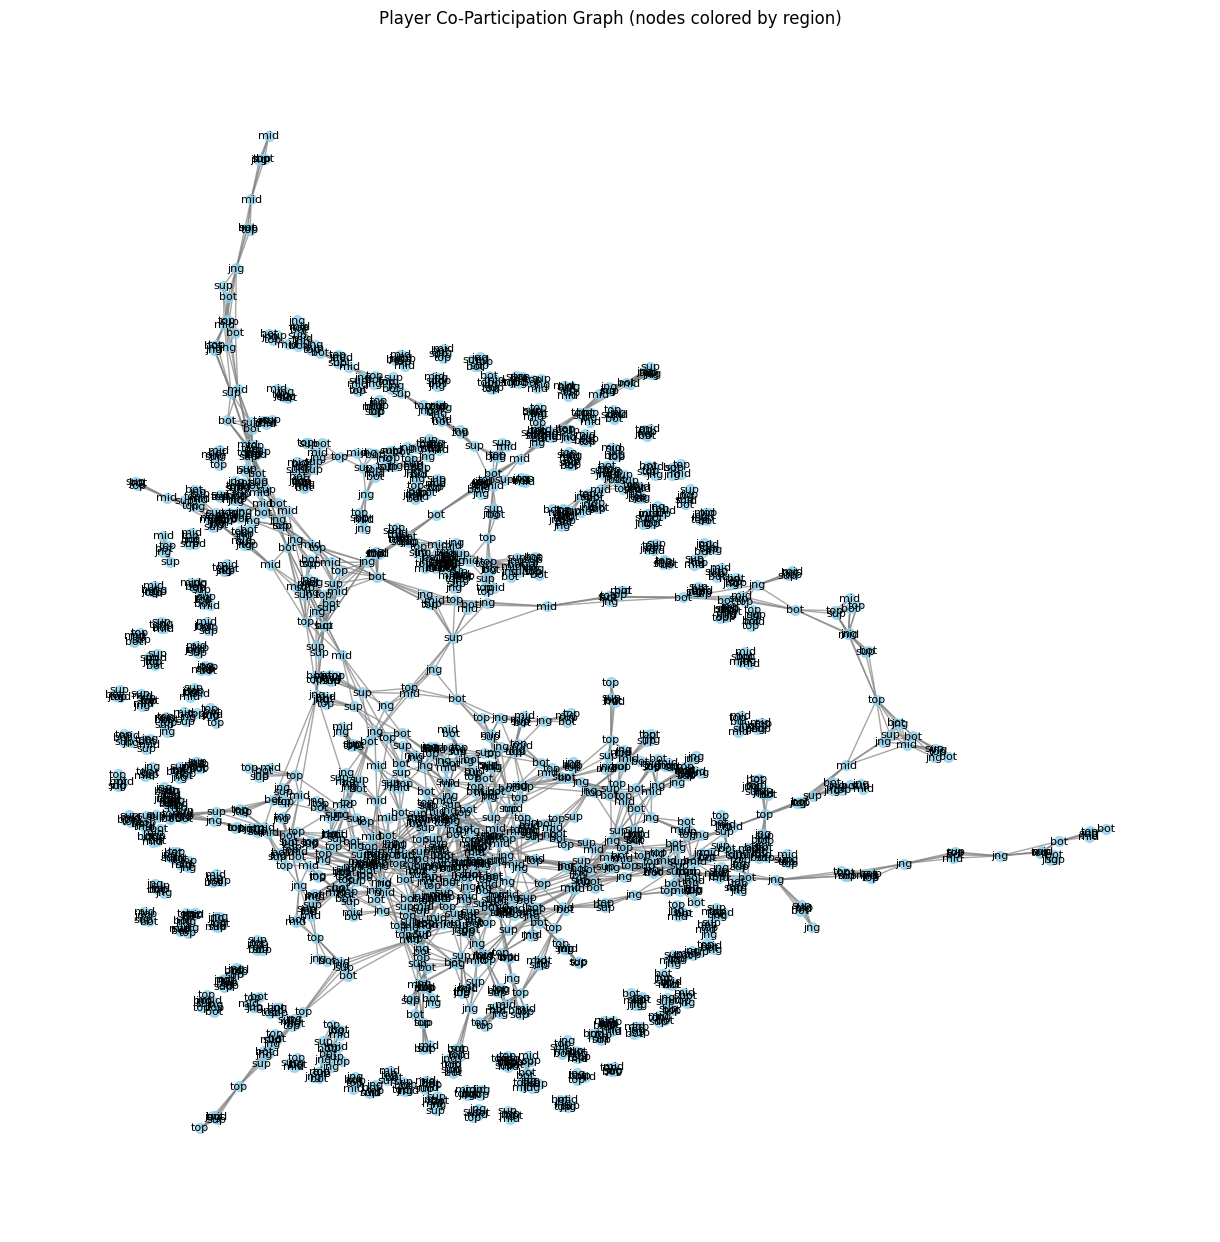

In [36]:
# Plot G with spring_layout
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G, seed=42)
labels = nx.get_node_attributes(G, 'label')
nx.draw(G, pos, with_labels=False, node_size=50, node_color='skyblue', edge_color='gray', alpha=0.7)
nx.draw_networkx_labels(G, pos, labels=labels, font_size=8)
plt.title("Player Co-Participation Graph (nodes colored by region)")
plt.axis('off')
plt.show()

In [37]:
print(f"G: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Roles (unique labels): {sorted(set(nx.get_node_attributes(G, 'label').values()))}\n")

results_mni = gspan_single_graph(
    G,
    min_support=2,
    max_nodes=4,
    measure="mni",
    verbose=True,
)
print_results(results_mni, "mni")

G: 1994 nodes, 5633 edges
Roles (unique labels): ['bot', 'jng', 'mid', 'sup', 'top']


  gSpan Single-Graph Mining
  Backend      : grandiso
  Measure      : MNI
  Min support  : 2
  Max nodes    : 4
  Graph        : 1994 nodes, 5633 edges
  Labels       : ['bot', 'jng', 'mid', 'sup', 'top']

  [seed] ['top', 'jng']  support=392
  [seed] ['top', 'mid']  support=384
  [seed] ['top', 'bot']  support=391
  [seed] ['top', 'sup']  support=393
  [seed] ['jng', 'mid']  support=383
  [seed] ['jng', 'bot']  support=391
  [seed] ['jng', 'sup']  support=403
  [seed] ['mid', 'bot']  support=384
  [seed] ['mid', 'sup']  support=383
  [seed] ['bot', 'bot']  support=22
  [seed] ['bot', 'sup']  support=389
  [seed] ['jng', 'jng']  support=16
  [seed] ['mid', 'mid']  support=22
  [seed] ['sup', 'sup']  support=30
  [seed] ['top', 'top']  support=18
  [ext]  ['top', 'top', 'top']  support=2
  [ext]  ['top', 'top', 'sup']  support=18
  [ext]  ['top', 'top', 'bot']  support=18
  [ext]  ['top', 'top', 'mid

In [38]:
results_db = gspan_graph_db(
    G,
    min_support=2,
    max_nodes=5,
    verbose=True,
)
print_results(results_db, "transaction")


  gSpan Graph-DB Mining
  Backend       : grandiso
  Transactions  : 131
  Min support   : 2
  Max nodes     : 5
  Labels        : ['bot', 'jng', 'mid', 'sup', 'top']

  [seed] ['top', 'jng']  support=131
  [seed] ['top', 'mid']  support=131
  [seed] ['top', 'bot']  support=131
  [seed] ['top', 'sup']  support=131
  [seed] ['jng', 'mid']  support=131
  [seed] ['jng', 'bot']  support=131
  [seed] ['jng', 'sup']  support=131
  [seed] ['mid', 'bot']  support=131
  [seed] ['mid', 'sup']  support=131
  [seed] ['bot', 'bot']  support=6
  [seed] ['bot', 'sup']  support=131
  [seed] ['jng', 'jng']  support=4
  [seed] ['mid', 'mid']  support=5
  [seed] ['sup', 'sup']  support=5
  [seed] ['top', 'top']  support=3
  [ext]  ['top', 'top', 'sup']  support=3
  [ext]  ['top', 'top', 'bot']  support=3
  [ext]  ['top', 'top', 'mid']  support=3
  [ext]  ['top', 'top', 'jng']  support=3
  [ext]  ['top', 'top', 'jng', 'sup']  support=3
  [ext]  ['top', 'top', 'jng', 'bot']  support=3
  [ext]  ['top', 'to

KeyboardInterrupt: 

In [ ]:
results_enum = gspan_graph_db_enum(
    G,
    min_support=2,
    max_nodes=5,
    verbose=True,
)
print_results(results_enum, "transaction-enum")


  gSpan Graph-DB Enum Mining
  Transactions  : 131
  Min support   : 2
  Max nodes     : 5



In [ ]:
data["teamid"].nunique()

100